## WEMABANK STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

wemabank=pd.read_csv('../stock_data/wemabank.csv') ## so it can be small letter. This is cool.
wemabank=wemabank.drop(columns=['high_price','low_price'])
wemabank.rename(columns={'trade_date':'date'},inplace=True)
wemabank['date']=pd.to_datetime(wemabank['date'])
wemabank['month']=wemabank['date'].dt.month
wemabank['quarter']=wemabank['date'].dt.quarter
wemabank['year']=wemabank['date'].dt.year

wemabank

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42812,WEMABANK,2017-01-03,0.55,0.55,803460,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43372,WEMABANK,2017-01-04,0.54,0.54,246599,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43482,WEMABANK,2017-01-05,0.53,0.53,450800,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43592,WEMABANK,2017-01-06,0.53,0.53,10856,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43682,WEMABANK,2017-01-09,0.51,0.51,247233,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298159,WEMABANK,2026-07-13,30.00,30.00,1873333,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298597,WEMABANK,2026-07-14,29.25,29.25,5515473,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,299035,WEMABANK,2026-07-15,29.40,29.40,4839680,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299473,WEMABANK,2026-07-16,30.00,30.00,17287296,2026-07-16T15:10:03.113936+00:00,7,3,2026


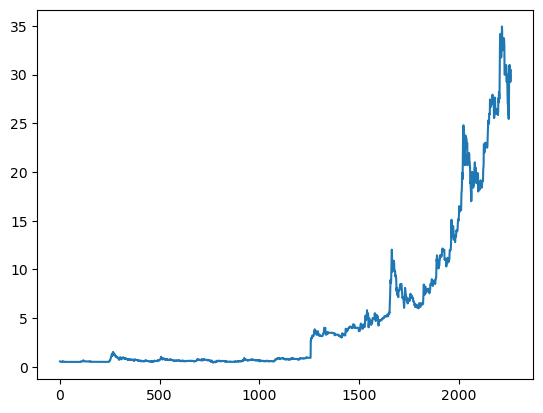

In [2]:
import matplotlib.pyplot as plt

plt.plot(wemabank['close_price'])
plt.show()

In [3]:
wemabank_end_month_df = (
    wemabank
    .sort_values("date")
    .groupby(wemabank["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

wemabank_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45382,WEMABANK,2017-01-31,0.51,0.51,1276842,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47204,WEMABANK,2017-02-28,0.50,0.50,230000,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49320,WEMABANK,2017-03-31,0.50,0.50,121851,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51148,WEMABANK,2017-04-28,0.50,0.50,528821,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53070,WEMABANK,2017-05-31,0.53,0.53,859449,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35398,WEMABANK,2026-03-31,26.00,26.00,184132655,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281223,WEMABANK,2026-04-30,34.10,34.10,68414432,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284289,WEMABANK,2026-05-29,33.50,33.50,3794806,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294217,WEMABANK,2026-06-30,26.00,26.00,4911119,2026-06-30T15:10:03.08168+00:00,6,2,2026


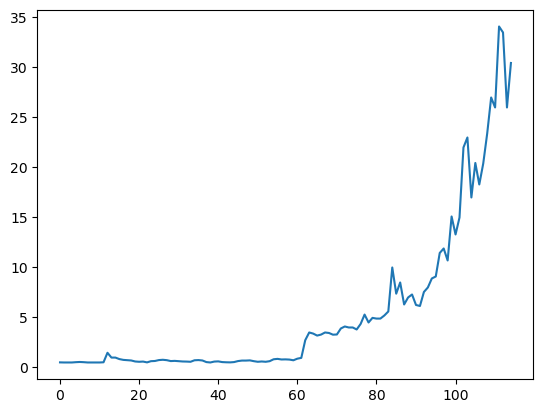

In [4]:
plt.plot(wemabank_end_month_df['close_price'])
plt.show()

In [5]:
wemabank_end_month_df['returns']=wemabank_end_month_df['close_price'].pct_change()*100
wemabank_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45382,WEMABANK,2017-01-31,0.51,0.51,1276842,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47204,WEMABANK,2017-02-28,0.50,0.50,230000,2026-04-08T02:44:45.006295+00:00,2,1,2017,-1.960784
2,49320,WEMABANK,2017-03-31,0.50,0.50,121851,2026-04-08T02:45:42.281198+00:00,3,1,2017,0.000000
3,51148,WEMABANK,2017-04-28,0.50,0.50,528821,2026-04-08T02:51:55.619599+00:00,4,2,2017,0.000000
4,53070,WEMABANK,2017-05-31,0.53,0.53,859449,2026-04-08T02:52:57.421655+00:00,5,2,2017,6.000000
...,...,...,...,...,...,...,...,...,...,...,...
110,35398,WEMABANK,2026-03-31,26.00,26.00,184132655,2026-03-31T15:00:02.085058+00:00,3,1,2026,-3.703704
111,281223,WEMABANK,2026-04-30,34.10,34.10,68414432,2026-04-30T15:00:02.170664+00:00,4,2,2026,31.153846
112,284289,WEMABANK,2026-05-29,33.50,33.50,3794806,2026-05-29T15:00:02.455558+00:00,5,2,2026,-1.759531
113,294217,WEMABANK,2026-06-30,26.00,26.00,4911119,2026-06-30T15:10:03.08168+00:00,6,2,2026,-22.388060


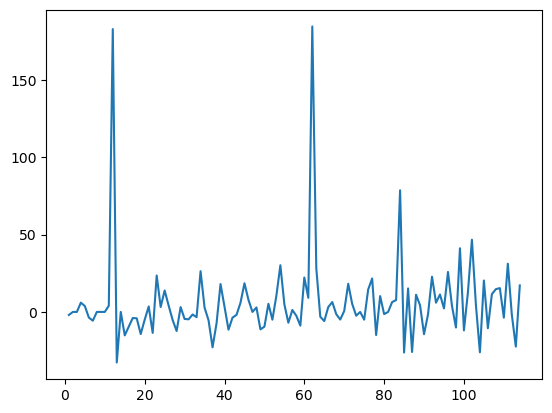

In [6]:
plt.plot(wemabank_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(wemabank_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(-11.163740375489516, 2.746950193161346e-20, 0, 113, {'1%': -3.489589552580676, '5%': -2.887477210140433, '10%': -2.580604145195395}, 922.210275283293)
stationary


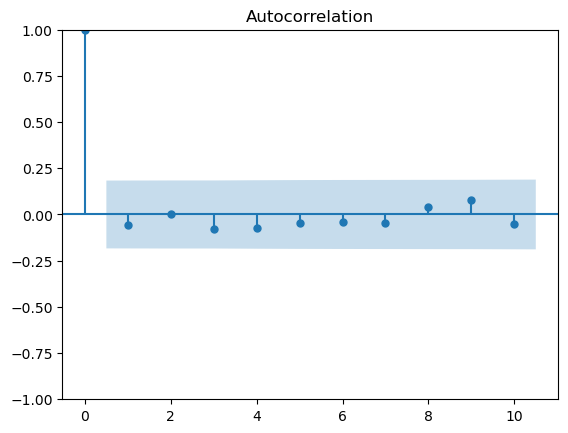

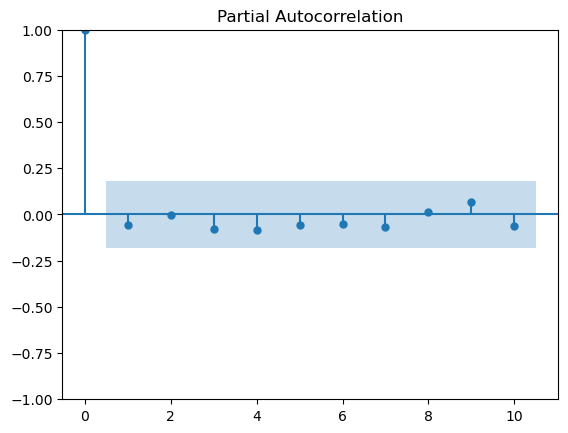

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(wemabank_end_month_df['returns'].dropna(), lags=10)
plot_pacf(wemabank_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=wemabank_end_month_df['close_price'][:-10]
test=wemabank_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -24.88090113306185]
[0, 0, 0, 0, 0, 1, -12.194588839398927]
[0, 0, 0, 0, 0, 2, -7.341108507674093]
[0, 0, 0, 0, 1, 0, -6.152789827917845]
[0, 0, 0, 0, 1, 1, -18.883559328462894]
[0, 0, 0, 0, 1, 2, -3.8112894942292064]
[0, 0, 0, 0, 2, 0, -2.4549045813511174]
[0, 0, 0, 0, 2, 1, -2.4948053364984175]
[0, 0, 0, 0, 2, 2, -2.5724917212570944]
[0, 0, 0, 1, 0, 0, -7.190693178019355]
[0, 0, 0, 1, 0, 1, -4.971904329471135]
[0, 0, 0, 1, 0, 2, -12.195708789021118]
[0, 0, 0, 1, 1, 0, -3.2613743286325487]
[0, 0, 0, 1, 1, 1, -3.3324551686127792]
[0, 0, 0, 1, 1, 2, -3.289872557508933]
[0, 0, 0, 1, 2, 0, -2.4717530670089203]
[0, 0, 0, 1, 2, 1, -2.4971751440758387]
[0, 0, 0, 1, 2, 2, -2.307282344195546]
[0, 0, 0, 2, 0, 0, -4.564927252855533]
[0, 0, 0, 2, 0, 1, -4.616884917778497]
[0, 0, 0, 2, 0, 2, -4.484835614849788]
[0, 0, 0, 2, 1, 0, -3.293705578222811]
[0, 0, 0, 2, 1, 1, -3.3286811242436265]
[0, 0, 0, 2, 1, 2, -3.3506420228537097]
[0, 0, 0, 2, 2, 0, -2.602935635014083]
[0, 0, 0, 2,

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
168,0,2,0,0,2,0,-111.040813
177,0,2,0,1,2,0,-92.608484
169,0,2,0,0,2,1,-92.226533
165,0,2,0,0,1,0,-90.962488
186,0,2,0,2,2,0,-87.327001
...,...,...,...,...,...,...,...
471,1,2,2,1,1,0,0.566363
482,1,2,2,2,1,2,0.588080
481,1,2,2,2,1,1,0.588756
220,0,2,2,0,1,1,0.601390


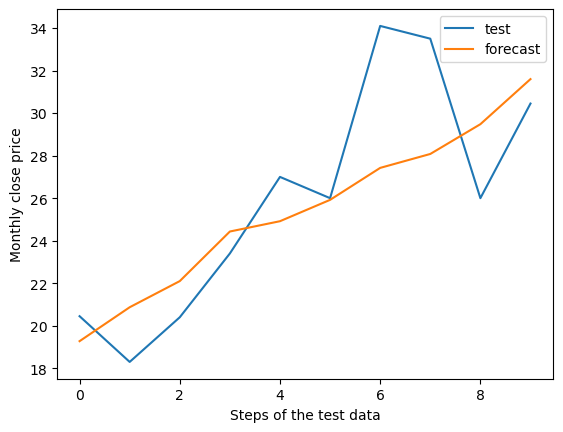

r2_score:  0.6172449368113015
rmse:  3.219823809779468
description:  count    115.000000
mean       5.404957
std        7.892612
min        0.500000
25%        0.605000
50%        0.880000
75%        6.275000
max       34.100000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=wemabank_end_month_df['close_price'][:-10]
y_test=wemabank_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(1,2,2), 
seasonal_order=(0,1,1,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', wemabank_end_month_df.close_price.describe())

Its not capturing the variations properly. Lets try the returns

In [12]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=wemabank_end_month_df['returns'].dropna()[:-10]
test=wemabank_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.21698155135931696]
[0, 0, 0, 0, 0, 1, -0.25775763736004964]
[0, 0, 0, 0, 0, 2, -0.2607521360649321]
[0, 0, 0, 0, 1, 0, -0.42091742660400877]
[0, 0, 0, 0, 1, 1, -0.6138133381681372]
[0, 0, 0, 0, 1, 2, -0.8237261357021644]
[0, 0, 0, 0, 2, 0, -7.940876837354772]
[0, 0, 0, 0, 2, 1, -0.7279227740624403]
[0, 0, 0, 0, 2, 2, -0.22062836182823364]
[0, 0, 0, 1, 0, 0, -0.25839383997184395]
[0, 0, 0, 1, 0, 1, -0.2876737749502445]
[0, 0, 0, 1, 0, 2, -0.5335065287817875]
[0, 0, 0, 1, 1, 0, -0.7684414421622441]
[0, 0, 0, 1, 1, 1, -0.8025620301384764]
[0, 0, 0, 1, 1, 2, -1.4221908777231969]
[0, 0, 0, 1, 2, 0, -2.0609985528014305]
[0, 0, 0, 1, 2, 1, -0.19310334906009308]
[0, 0, 0, 1, 2, 2, -0.18131905443490437]
[0, 0, 0, 2, 0, 0, -0.26026177650987914]
[0, 0, 0, 2, 0, 1, -0.44976471267516804]
[0, 0, 0, 2, 0, 2, -0.6115728156778752]
[0, 0, 0, 2, 1, 0, -0.6465548607528175]
[0, 0, 0, 2, 1, 1, -0.7086823408200378]
[0, 0, 0, 2, 1, 2, -1.4272608294651037]
[0, 0, 0, 2, 2, 0, -4.0024827075

In [13]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
702,2,2,2,0,0,2,-1.726926e+07
168,0,2,0,0,2,0,-1.573139e+03
410,1,2,0,0,2,0,-9.538116e+02
428,1,2,0,2,2,0,-9.181317e+02
419,1,2,0,1,2,0,-8.423856e+02
...,...,...,...,...,...,...,...
370,1,1,1,2,0,2,-1.044913e-02
108,0,1,1,0,0,0,-6.630859e-03
135,0,1,2,0,0,0,6.738772e-03
350,1,1,1,0,0,0,7.462713e-03


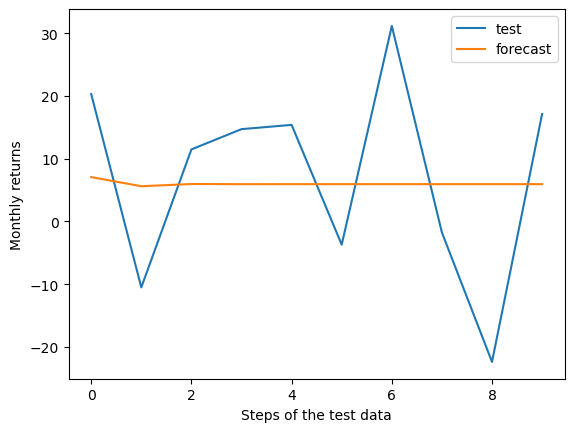

r2_score:  0.011243434648029016
rmse:  15.319445128701439
description:  count    114.000000
mean       6.030332
std       28.256461
min      -32.653061
25%       -4.981884
50%        0.304878
75%       10.450292
max      184.375000
Name: returns, dtype: float64


In [14]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=wemabank_end_month_df['returns'].dropna()[:-10]
y_test=wemabank_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,1,1), 
seasonal_order=(0,0,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly returns')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', wemabank_end_month_df.returns.dropna().describe())

Very horrible. We will work with close_price
